# 생성형 인공지능 3주차 실습
## 확산 모델에 대한 우도 극대화 (Maximum Likelihood for Diffusion Models)

**대상**: 학부 4학년 / **환경**: Google Colab (CPU만으로 수 분 내 완주 가능) / **총 6문제**

---

### 학습 목표
이번 실습에서는 강의에서 다룬 *"확산 모델의 로그 우도를 어떻게 극대화하는가"* 라는 질문을
세 갈래로 나누어 직접 코드로 구현하고 **수치적으로 검증**한다.

| # | 주제 | 강의 대응 |
|---|------|-----------|
| 1 | 선형 / 코사인 노이즈 추가 전략 | 노이즈 추가 전략의 최적화 |
| 2 | 순방향 프로세스와 사후분포 $q(x_{t-1}\mid x_t, x_0)$ | 확산 모델링의 고전적 프레임워크 |
| 3 | IDDPM: 학습 가능한 역분산과 변분 하한 $L_\mathrm{VLB}$ | 역 분산 학습 |
| 4 | VDM: 학습 가능한 단조 노이즈 스케줄 $\gamma_\eta(t)$ | 변동 확산 모델 (VDM) |
| 5 | Analytic-DPM: 최적 역분산의 해석적 형태 (식 4.4) | 역 분산 학습 |
| 6 | 확률 흐름 ODE + 스킬링–허친슨 대각합 추정기 | 정확한 로그 우도 추정 |

### 채점 방식
각 문제마다 `### 검증` 코드 셀이 붙어 있다. `assert` 가 하나도 터지지 않고
`✅ 문제 N 통과` 가 출력되면 정답이다. **검증 셀은 수정하지 말 것.**

### 표기 약속 (전 문제 공통)
- 이산 시간: $t = 1,\dots,T$, $\alpha_t = 1-\beta_t$, $\bar\alpha_t = \prod_{s\le t}\alpha_s$
- 순방향: $q(x_t\mid x_0)=\mathcal N\!\big(\sqrt{\bar\alpha_t}\,x_0,\ (1-\bar\alpha_t)I\big)$
- 코드에서 시간 인덱스는 **0-based** (`t=0` ↔ 수식의 $t=1$)


## 0. 준비

Colab 기본 런타임에 이미 설치된 PyTorch / NumPy / Matplotlib 만 사용한다.

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)   # 수치 검증을 위해 배정밀도 사용
torch.manual_seed(0)
np.random.seed(0)

DEVICE = "cpu"
print("torch", torch.__version__)


def check(name, got, expected, tol=1e-8):
    """스칼라/텐서 비교 헬퍼."""
    got = torch.as_tensor(got, dtype=torch.float64)
    expected = torch.as_tensor(expected, dtype=torch.float64)
    err = (got - expected).abs().max().item()
    scale = max(1.0, expected.abs().max().item())
    assert err / scale < tol, f"[{name}] 최대 오차 {err:.3e} (허용 {tol:.1e})"
    print(f"  ok  {name}: 최대 오차 {err:.3e}")

torch 2.10.0


---
# 문제 1. 노이즈 추가 전략 — 선형 보간 vs 코사인 스케줄

### 배경
확산 모델의 순방향 프로세스는 **학습 파라미터가 없는 수작업 스케줄** $\{\beta_t\}$ 로 정해진다.
따라서 스케줄을 어떻게 고르느냐가 곧 우도의 상한을 결정한다.
개선된 DDPM(IDDPM)은 선형 스케줄이 이미지의 정보를 **너무 빨리** 파괴한다고 지적하고
다음 코사인 전략을 제안했다.

$$\bar\alpha_t = \frac{h(t)}{h(0)},\qquad
h(t) = \cos^2\!\Big(\frac{\tfrac{t}{T}+m}{1+m}\cdot\frac{\pi}{2}\Big)$$

여기서 $m$ 은 작은 오프셋(강의 코드의 `s = 0.008`)이며,
$\beta_t = 1 - \bar\alpha_t/\bar\alpha_{t-1}$ 로 되돌려 계산한다.

### 과제
1. `linear_beta_schedule(T)` — $\beta_1 = \frac{1000}{T}\!\cdot\!10^{-4}$ 에서 $\beta_T = \frac{1000}{T}\!\cdot\!0.02$ 까지 등간격.
2. `cosine_beta_schedule(T, s=0.008)` — 위 식으로 $\bar\alpha$ 를 만든 뒤 $\beta$ 로 환산, $[0,\,0.999]$ 로 clip.
3. `alpha_bar_from_betas(betas)` — 누적곱 $\bar\alpha_t$.
4. 두 스케줄의 $\bar\alpha_t$ 와 **로그 신호대잡음비** $\log \mathrm{SNR}(t)=\log\frac{\bar\alpha_t}{1-\bar\alpha_t}$ 를 한 그림에 그리고,
   "코사인이 왜 정보를 천천히 파괴하는가"를 셀 아래 주석으로 한 줄 적을 것.

In [2]:
def linear_beta_schedule(timesteps: int) -> torch.Tensor:
    """beta_1 = (1000/T)*1e-4 부터 beta_T = (1000/T)*0.02 까지 등간격."""
    scale = 1000 / timesteps
    return torch.linspace(scale * 1e-4, scale * 0.02, timesteps)


def cosine_beta_schedule(timesteps: int, s: float = 0.008) -> torch.Tensor:
    """abar_t = h(t)/h(0), h(t)=cos^2(((t/T)+s)/(1+s) * pi/2) 로부터 beta 를 복원."""
    x = torch.linspace(0, timesteps, timesteps + 1)
    h = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi / 2).square()
    abar = h / h[0]
    betas = 1.0 - abar[1:] / abar[:-1]
    return betas.clamp(0.0, 0.999)


def alpha_bar_from_betas(betas: torch.Tensor) -> torch.Tensor:
    """누적곱 abar_t = prod_{s<=t} (1 - beta_s)."""
    return torch.cumprod(1.0 - betas, dim=0)


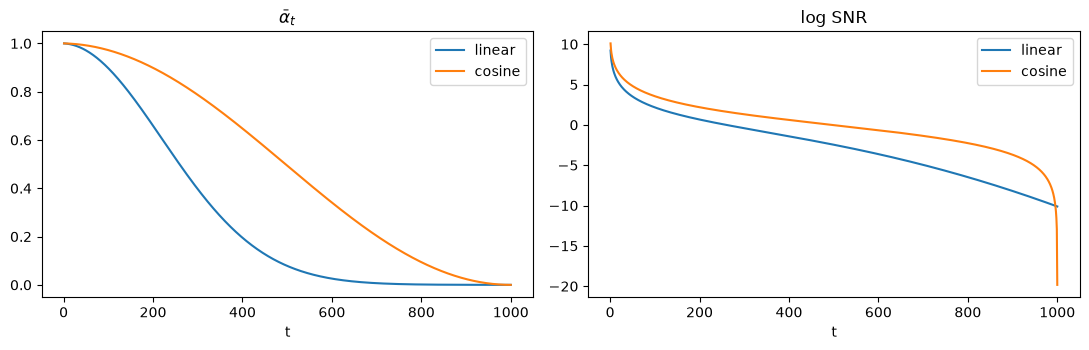

In [3]:
T = 1000
b_lin, b_cos = linear_beta_schedule(T), cosine_beta_schedule(T)
ab_lin, ab_cos = alpha_bar_from_betas(b_lin), alpha_bar_from_betas(b_cos)

t_axis = torch.arange(1, T + 1)
logsnr = lambda ab: torch.log(ab / (1 - ab))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(t_axis, ab_lin, label="linear")
ax[0].plot(t_axis, ab_cos, label="cosine")
ax[0].set_title(r"$\bar{\alpha}_t$")
ax[0].set_xlabel("t")
ax[0].legend()
ax[1].plot(t_axis, logsnr(ab_lin), label="linear")
ax[1].plot(t_axis, logsnr(ab_cos), label="cosine")
ax[1].set_title(r"log SNR")
ax[1].set_xlabel("t")
ax[1].legend()
plt.tight_layout(); plt.show()

# 코사인 스케줄은 초반과 중반의 alpha_bar를 크게 유지해 유용한 신호를 더 천천히 파괴한다.


In [4]:
### 검증 (수정 금지)
assert b_lin.shape == (T,) and b_cos.shape == (T,)
check("linear beta 시작", b_lin[0], 1e-4)
check("linear beta 끝",  b_lin[-1], 0.02)
assert torch.all(b_cos >= 0) and torch.all(b_cos <= 0.999), "cosine beta 범위 위반"
assert torch.all(torch.diff(ab_cos) < 0) and torch.all(torch.diff(ab_lin) < 0), "abar 는 감소해야 함"

# abar_t 가 정말 h(t)/h(0) 인가?
s_ = 0.008
h = lambda t: math.cos(((t / T) + s_) / (1 + s_) * math.pi / 2) ** 2
ref = torch.tensor([h(t) / h(0.0) for t in range(1, T + 1)])
check("cosine abar == h(t)/h(0)", ab_cos, ref, tol=1e-6)

# 선형 스케줄은 코사인보다 훨씬 빨리 정보를 파괴한다
assert ab_lin[T // 2] * 3 < ab_cos[T // 2], "선형/코사인 붕괴 속도 비교 실패"
print("✅ 문제 1 통과")

  ok  linear beta 시작: 최대 오차 0.000e+00
  ok  linear beta 끝: 최대 오차 0.000e+00
  ok  cosine abar == h(t)/h(0): 최대 오차 2.429e-09
✅ 문제 1 통과


---
# 문제 2. 순방향 프로세스와 사후분포 $q(x_{t-1}\mid x_t, x_0)$

### 배경
DDPM 의 손실은 결국 각 시점에서
$D_{\mathrm{KL}}\big(q(x_{t-1}\mid x_t,x_0)\,\|\,p_\theta(x_{t-1}\mid x_t)\big)$
를 최소화하는 문제로 분해된다 (강의: "쿨백–라이블러 발산 속성을 사용하여 ... 각 단계의 합으로 분할").
따라서 **정답 쪽 분포** $q(x_{t-1}\mid x_t,x_0)$ 를 정확히 계산할 수 있어야 한다.

$$q(x_{t-1}\mid x_t, x_0)=\mathcal N\big(\tilde\mu_t(x_t,x_0),\ \tilde\beta_t I\big)$$
$$\tilde\beta_t=\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t,\qquad
\tilde\mu_t=\frac{\sqrt{\bar\alpha_{t-1}}\,\beta_t}{1-\bar\alpha_t}x_0
+\frac{\sqrt{\alpha_t}\,(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}x_t$$

### 과제
`DiffusionSchedule` 클래스의 세 메서드를 채우시오.
1. `q_sample(x0, t, noise)` — $x_t = \sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon$
2. `q_posterior(x0, xt, t)` — $(\tilde\mu_t,\ \tilde\beta_t,\ \log\tilde\beta_t)$ 반환
3. `predict_x0_from_eps(xt, t, eps)` — $\hat x_0=\frac{x_t-\sqrt{1-\bar\alpha_t}\,\varepsilon}{\sqrt{\bar\alpha_t}}$

> **검증 아이디어**: $x_0$ 가 주어지면 $(x_{t-1},x_t)$ 는 **이변량 정규분포**이므로
> 조건부 평균/분산을 공분산 행렬로부터 직접 구할 수 있다. 두 결과가 기계 정밀도까지
> 일치해야 한다. ($t=1$ 에서 $\tilde\beta_1=0$ 이 되므로 로그 분산은 clip 이 필요하다.)

In [5]:
class DiffusionSchedule:
    def __init__(self, betas: torch.Tensor):
        self.betas = betas
        self.T = betas.shape[0]
        self.alphas = 1.0 - betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat(
            [torch.ones(1, dtype=betas.dtype), self.alphas_cumprod[:-1]])

        ab, ab_prev, a = self.alphas_cumprod, self.alphas_cumprod_prev, self.alphas
        self.posterior_variance = (1.0 - ab_prev) / (1.0 - ab) * betas
        self.posterior_c0 = torch.sqrt(ab_prev) * betas / (1.0 - ab)
        self.posterior_ct = torch.sqrt(a) * (1.0 - ab_prev) / (1.0 - ab)
        self.posterior_log_variance_clipped = torch.log(
            torch.cat([self.posterior_variance[1:2], self.posterior_variance[1:]]))

    def q_sample(self, x0, t, noise):
        """x_t = sqrt(abar_t) x0 + sqrt(1-abar_t) * noise"""
        ab = self.alphas_cumprod[t]
        return torch.sqrt(ab) * x0 + torch.sqrt(1.0 - ab) * noise

    def q_posterior(self, x0, xt, t):
        """(mu_tilde, beta_tilde, log beta_tilde(clipped)) 를 반환."""
        mean = self.posterior_c0[t] * x0 + self.posterior_ct[t] * xt
        return mean, self.posterior_variance[t], self.posterior_log_variance_clipped[t]

    def predict_x0_from_eps(self, xt, t, eps):
        """x0_hat = (x_t - sqrt(1-abar_t) eps) / sqrt(abar_t)"""
        ab = self.alphas_cumprod[t]
        return (xt - torch.sqrt(1.0 - ab) * eps) / torch.sqrt(ab)


sched = DiffusionSchedule(cosine_beta_schedule(1000))


In [6]:
### 검증 (수정 금지)
x0 = torch.tensor(0.7)

# (a) q_sample 의 경험적 평균/분산
t = 500
eps = torch.randn(200_000)
xt = sched.q_sample(x0, t, eps)
check("q_sample 평균", xt.mean(), torch.sqrt(sched.alphas_cumprod[t]) * x0, tol=2e-2)
check("q_sample 분산", xt.var(), 1 - sched.alphas_cumprod[t], tol=2e-2)

# (b) 사후분포를 이변량 정규분포 조건부 공식과 대조
for t in [1, 7, 123, 500, 999]:
    ab_p, ab_t, a_t = sched.alphas_cumprod_prev[t], sched.alphas_cumprod[t], sched.alphas[t]
    V_prev, V_t = 1 - ab_p, 1 - ab_t
    Cov = torch.sqrt(a_t) * V_prev                       # Cov(x_{t-1}, x_t | x0)
    exact_var = V_prev - Cov ** 2 / V_t
    xt_ = torch.tensor(1.3)
    exact_mean = torch.sqrt(ab_p) * x0 + Cov / V_t * (xt_ - torch.sqrt(ab_t) * x0)
    mean, var, _ = sched.q_posterior(x0, xt_, t)
    check(f"posterior var  (t={t})", var, exact_var, tol=1e-9)
    check(f"posterior mean (t={t})", mean, exact_mean, tol=1e-9)

# (c) predict_x0_from_eps 는 q_sample 의 역함수
t = 321
eps = torch.randn(1000)
check("x0 복원", sched.predict_x0_from_eps(sched.q_sample(x0, t, eps), t, eps),
      x0.expand(1000), tol=1e-8)
print("✅ 문제 2 통과")

  ok  q_sample 평균: 최대 오차 8.681e-04
  ok  q_sample 분산: 최대 오차 3.253e-04
  ok  posterior var  (t=1): 최대 오차 2.590e-17
  ok  posterior mean (t=1): 최대 오차 4.391e-13
  ok  posterior var  (t=7): 최대 오차 1.648e-17
  ok  posterior mean (t=7): 최대 오차 2.953e-14
  ok  posterior var  (t=123): 최대 오차 8.457e-18
  ok  posterior mean (t=123): 최대 오차 2.220e-16
  ok  posterior var  (t=500): 최대 오차 1.132e-16
  ok  posterior mean (t=500): 최대 오차 0.000e+00
  ok  posterior var  (t=999): 최대 오차 1.110e-16
  ok  posterior mean (t=999): 최대 오차 0.000e+00
  ok  x0 복원: 최대 오차 3.331e-16
✅ 문제 2 통과


---
# 문제 3. IDDPM — 학습 가능한 역분산과 변분 하한

### 배경
DDPM 은 역방향 분산을 $\beta_t$ 또는 $\tilde\beta_t$ 로 **고정**했다.
IDDPM 은 이 둘 사이를 **로그 영역에서 보간**하는 방식으로 역분산을 파라미터화하여 학습한다.

$$\Sigma_\theta(x_t,t)=\exp\big(v\cdot\log\beta_t+(1-v)\cdot\log\tilde\beta_t\big),
\qquad v=\tfrac{1}{2}(v_\text{raw}+1)\in[0,1]$$

(신경망은 $v_\text{raw}\in[-1,1]$ 을 출력한다고 본다.)
그리고 각 시점의 손실은 두 가우시안 사이의 KL 이다.

$$D_{\mathrm{KL}}\big(\mathcal N(\mu_1,\sigma_1^2)\|\mathcal N(\mu_2,\sigma_2^2)\big)
=\tfrac12\Big(-1+\log\sigma_2^2-\log\sigma_1^2+\frac{\sigma_1^2}{\sigma_2^2}
+\frac{(\mu_1-\mu_2)^2}{\sigma_2^2}\Big)$$

IDDPM 의 실제 구현에서는 **평균은 MSE 손실이, 분산만 VLB 손실이** 학습하도록
평균 예측에 `.detach()` 를 걸어 그래디언트를 차단한다 (강의 코드의 `frozen_out`).

### 과제
1. `normal_kl(mean1, logvar1, mean2, logvar2)` — 위 식 (로그 분산 입력).
2. `learned_range_logvar(v_raw, t, sched)` — 위 보간식의 **로그 분산** 반환.
3. `vb_term(sched, x0, xt, t, eps_pred, v_raw)` — 시점 $t$ 의 $L_{t-1}$ 항 (nats).
   - 예측 평균은 `eps_pred` → `predict_x0_from_eps` → `q_posterior` 순으로 구한다.
   - **`eps_pred` 는 반드시 `.detach()` 하여** 분산만 이 항에서 학습되도록 한다.

In [7]:
def normal_kl(mean1, logvar1, mean2, logvar2):
    """두 대각 가우시안 사이의 KL. 입력은 평균과 '로그' 분산."""
    return 0.5 * (logvar2 - logvar1 - 1.0
                  + torch.exp(logvar1 - logvar2)
                  + (mean1 - mean2).square() * torch.exp(-logvar2))


def learned_range_logvar(v_raw, t, sched):
    """log Sigma_theta = v*log(beta_t) + (1-v)*log(beta_tilde_t),  v=(v_raw+1)/2"""
    v = (v_raw + 1.0) / 2.0
    log_beta = torch.log(sched.betas[t])
    log_beta_tilde = sched.posterior_log_variance_clipped[t]
    return v * log_beta + (1.0 - v) * log_beta_tilde


def vb_term(sched, x0, xt, t, eps_pred, v_raw):
    """시점 t 의 변분 하한 항 L_{t-1}."""
    x0_hat = sched.predict_x0_from_eps(xt, t, eps_pred.detach())
    true_mean, _, true_logvar = sched.q_posterior(x0, xt, t)
    model_mean, _, _ = sched.q_posterior(x0_hat, xt, t)
    model_logvar = learned_range_logvar(v_raw, t, sched)
    return normal_kl(true_mean, true_logvar, model_mean, model_logvar)


In [8]:
### 검증 (수정 금지)
# (a) normal_kl 을 torch.distributions 와 대조
m1, s1 = torch.tensor(0.3), torch.tensor(0.8)
m2, s2 = torch.tensor(-0.2), torch.tensor(1.4)
ref = torch.distributions.kl_divergence(
    torch.distributions.Normal(m1, s1), torch.distributions.Normal(m2, s2))
check("normal_kl", normal_kl(m1, 2 * torch.log(s1), m2, 2 * torch.log(s2)), ref, tol=1e-10)
check("normal_kl 자기자신=0", normal_kl(m1, 2 * torch.log(s1), m1, 2 * torch.log(s1)), 0.0)

# (b) 보간의 양 끝점
t = 400
check("v_raw=-1 -> beta_tilde", torch.exp(learned_range_logvar(torch.tensor(-1.0), t, sched)),
      sched.posterior_variance[t], tol=1e-9)
check("v_raw=+1 -> beta",       torch.exp(learned_range_logvar(torch.tensor(1.0), t, sched)),
      sched.betas[t], tol=1e-9)
mid = torch.exp(learned_range_logvar(torch.tensor(0.0), t, sched))
assert min(sched.posterior_variance[t], sched.betas[t]) <= mid <= max(sched.posterior_variance[t], sched.betas[t])

# (c) eps 를 정확히 맞히면 평균 항이 사라져 KL 은 분산 항만 남는다
torch.manual_seed(3)
x0 = torch.randn(())
t = 250
eps = torch.randn(())
xt = sched.q_sample(x0, t, eps)
v_raw = torch.tensor(-1.0)                       # 분산도 정답(beta_tilde)으로 맞춤
check("완벽 예측 -> KL=0", vb_term(sched, x0, xt, t, eps, v_raw), 0.0, tol=1e-9)

# (d) 분산만 학습되는가? (평균 경로 차단 확인)
eps_pred = torch.randn((), requires_grad=True)
v = torch.zeros((), requires_grad=True)
loss = vb_term(sched, x0, xt, t, eps_pred, v)
loss.backward()
assert v.grad is not None and v.grad.abs() > 0, "v_raw 로 그래디언트가 흐르지 않음"
assert eps_pred.grad is None or eps_pred.grad.abs() < 1e-12, \
    "eps_pred 를 detach 해야 한다 (IDDPM 의 frozen_out)"
print("✅ 문제 3 통과")

  ok  normal_kl: 최대 오차 5.551e-17
  ok  normal_kl 자기자신=0: 최대 오차 0.000e+00
  ok  v_raw=-1 -> beta_tilde: 최대 오차 8.674e-19
  ok  v_raw=+1 -> beta: 최대 오차 0.000e+00
  ok  완벽 예측 -> KL=0: 최대 오차 0.000e+00
✅ 문제 3 통과


---
# 문제 4. VDM — 학습 가능한 단조 노이즈 스케줄

### 배경
변동 확산 모델(VDM)은 노이즈 추가 전략 자체를 **학습 대상**으로 만든다.
로그 신호대잡음비의 음수 $\gamma(t) = -\log \mathrm{SNR}(t)$ 를 신경망으로 두면

$$\bar\alpha(t)=\sigma(-\gamma(t)),\qquad \sigma^2(t)=\sigma(\gamma(t)),\qquad
\bar\alpha(t)+\sigma^2(t)=1$$

이 되어 VP 확산이 자동으로 만족된다. 단, $\gamma$ 는 **단조 증가**여야 한다.
강의 코드는 `register_parametrization` 으로 모든 선형층 가중치를 음이 아니게 강제하여
이를 보장했다.

$$\hat\gamma(t)=\ell_1(t)+\ell_3\big(\mathrm{sigmoid}(\ell_2(\ell_1(t)))\big),\qquad
\gamma(t)=\gamma_0+(\gamma_1-\gamma_0)\cdot
\frac{\hat\gamma(t)-\hat\gamma(0)}{\hat\gamma(1)-\hat\gamma(0)}$$

**핵심 사실**: VDM 의 확산 손실은 $\gamma$ 를 적분 변수로 바꾸면

$$L_D=\tfrac12\,\mathbb E_{x_0,\epsilon}\!\int_{\gamma_0}^{\gamma_1}
\|\epsilon-\hat\epsilon_\theta(x_\gamma,\gamma)\|^2\,d\gamma$$

즉 **양 끝점 $\gamma_0,\gamma_1$ 만 값에 영향을 주고 스케줄의 "모양"은 기댓값에 영향이 없다.**
스케줄 모양은 오직 **몬테카를로 추정량의 분산**만 바꾼다 — 그래서 VDM 은 스케줄을
"분산 최소화"로 학습한다.

### 과제
1. `Nonnegative` / `NoiseScheduleNet` 을 완성하여 단조 증가 $\gamma_\eta(t)$ 를 만든다.
2. `gamma_to_alpha_sigma(gamma)` — $(\bar\alpha,\ \sigma)$ 반환.
3. 두 가지 $L_D$ 추정량을 구현하고 **평균은 같고 분산은 다름**을 확인한다.
   - `ld_uniform_t` : $t\sim U(0,1)$, 가중치 $\gamma'(t)$ (autograd 로 계산)
   - `ld_uniform_gamma` : $\gamma\sim U(\gamma_0,\gamma_1)$, 가중치 $(\gamma_1-\gamma_0)$

In [9]:
import torch.nn.utils.parametrize as parametrize


class Nonnegative(nn.Module):
    def forward(self, X):
        return F.softplus(X)


class NoiseScheduleNet(nn.Module):
    """단조 증가하는 gamma(t) = -log SNR(t).  t in [0,1] -> gamma in [gamma0, gamma1]."""
    def __init__(self, hidden=64, gamma0=-9.0, gamma1=1.0):
        super().__init__()
        self.l1 = nn.Linear(1, 1, bias=True)
        self.l2 = nn.Linear(1, hidden, bias=True)
        self.l3 = nn.Linear(hidden, 1, bias=False)
        for layer in (self.l1, self.l2, self.l3):
            parametrize.register_parametrization(layer, "weight", Nonnegative())
        self.gamma0 = nn.Parameter(torch.tensor([gamma0]))
        self.gamma1 = nn.Parameter(torch.tensor([gamma1]))
        self.register_buffer("t01", torch.tensor([[0.0], [1.0]]))

    def gamma_hat(self, t):
        first = self.l1(t)
        return first + self.l3(torch.sigmoid(self.l2(first)))

    def forward(self, t):
        t = t.reshape(-1, 1).clamp(0.0, 1.0)
        endpoints = self.gamma_hat(self.t01)
        values = self.gamma_hat(t)
        normalized = (values - endpoints[0]) / (endpoints[1] - endpoints[0])
        return self.gamma0 + (self.gamma1 - self.gamma0) * normalized


def gamma_to_alpha_sigma(gamma):
    """abar = sigmoid(-gamma), sigma = sqrt(sigmoid(gamma)) 를 반환."""
    return torch.sigmoid(-gamma), torch.sqrt(torch.sigmoid(gamma))


torch.manual_seed(1)
gnet = NoiseScheduleNet()


### 4-2. 두 가지 $L_D$ 추정량

토이 설정: $x_0\sim\mathcal N(0, s^2)$ 이면 **최적 디노이저**를 해석적으로 안다.
$$\hat\epsilon^\star(x_\gamma,\gamma)=\frac{\sigma(\gamma)}{\bar\alpha(\gamma)s^2+\sigma^2(\gamma)}\,x_\gamma$$
이 $\hat\epsilon^\star$ 은 $(x,\gamma)$ 만의 함수이므로, 위에서 말한 **스케줄 모양 불변성**이
그대로 성립해야 한다.

In [12]:
S2 = 1.5   # 데이터 분산


def eps_hat_star(x, gamma):
    """x0 ~ N(0,S2) 에 대한 최적(베이즈) 노이즈 예측기."""
    abar, sigma = gamma_to_alpha_sigma(gamma)
    return sigma / (abar * S2 + sigma.square()) * x


def squared_error_at_gamma(gamma, gen):
    """주어진 gamma 들에서 ||eps - eps_hat||^2 을 1회 몬테카를로 샘플."""
    gamma = torch.as_tensor(gamma, dtype=torch.float64).reshape(-1)
    abar, sigma = gamma_to_alpha_sigma(gamma)
    x0 = torch.randn(gamma.shape, generator=gen, dtype=gamma.dtype)
    eps = torch.randn(gamma.shape, generator=gen, dtype=gamma.dtype)
    x = torch.sqrt(abar) * math.sqrt(S2) * x0 + sigma * eps
    return (eps - eps_hat_star(x, gamma)).square()


def ld_uniform_t(gnet, n, gen):
    """t ~ U(0,1) 가중 추정량의 개별 표본들."""
    t = torch.rand(n, generator=gen, requires_grad=True)
    gamma = gnet(t).reshape(-1)
    dgamma_dt = torch.autograd.grad(gamma.sum(), t, create_graph=True)[0]
    return dgamma_dt * squared_error_at_gamma(gamma, gen)


def ld_uniform_gamma(gnet, n, gen):
    """gamma ~ U(gamma0, gamma1) 표본들."""
    u = torch.rand(n, generator=gen)
    gamma0, gamma1 = gnet.gamma0[0], gnet.gamma1[0]
    gamma = gamma0 + (gamma1 - gamma0) * u
    return (gamma1 - gamma0) * squared_error_at_gamma(gamma, gen)


In [13]:
### 검증 (수정 금지)
tt = torch.linspace(0, 1, 501)
with torch.no_grad():
    gg = gnet(tt)
assert torch.all(torch.diff(gg) > -1e-8), "gamma(t) 가 단조 증가가 아님"
check("gamma(0) = gamma0", gg[0], gnet.gamma0.detach()[0], tol=1e-8)
check("gamma(1) = gamma1", gg[-1], gnet.gamma1.detach()[0], tol=1e-8)

ab, sig = gamma_to_alpha_sigma(gg)
check("abar + sigma^2 = 1", ab + sig ** 2, torch.ones_like(ab), tol=1e-12)
check("SNR = exp(-gamma)", ab / sig ** 2, torch.exp(-gg), tol=1e-8)

# 두 추정량의 평균이 (몬테카를로 오차 내에서) 일치하는가?
gen = torch.Generator().manual_seed(7)
N = 100_000
sa = ld_uniform_t(gnet, N, gen).detach()
sb = ld_uniform_gamma(gnet, N, gen).detach()
ma, mb = sa.mean().item(), sb.mean().item()
se = (sa.std().item() ** 2 / N + sb.std().item() ** 2 / N) ** 0.5
print(f"  L_D(uniform t)     = {ma:.5f}   표본분산 {sa.var().item():.4f}")
print(f"  L_D(uniform gamma) = {mb:.5f}   표본분산 {sb.var().item():.4f}")
print(f"  차이 {abs(ma-mb):.5f}  (허용 5*SE = {5*se:.5f})")
assert abs(ma - mb) < 5 * se + 1e-6, "두 추정량의 기댓값이 달라졌다 (스케줄 모양 불변성 위배)"

# 스케줄 파라미터로 그래디언트가 흐르는가? (= 학습 가능한 스케줄)
gen2 = torch.Generator().manual_seed(11)
loss_var = ld_uniform_t(gnet, 4096, gen2).var()
gnet.zero_grad(); loss_var.backward()
gnorm = sum((p.grad ** 2).sum() for p in gnet.parameters() if p.grad is not None) ** 0.5
assert gnorm > 0, "스케줄 파라미터로 그래디언트가 흐르지 않음"
print(f"  분산 손실의 그래디언트 노름 = {gnorm.item():.4e}")
print("✅ 문제 4 통과")

  ok  gamma(0) = gamma0: 최대 오차 2.487e-14
  ok  gamma(1) = gamma1: 최대 오차 0.000e+00
  ok  abar + sigma^2 = 1: 최대 오차 2.220e-16
  ok  SNR = exp(-gamma): 최대 오차 1.819e-12
  L_D(uniform t)     = 9.02260   표본분산 170.9731
  L_D(uniform gamma) = 8.89251   표본분산 166.6860
  차이 0.13009  (허용 5*SE = 0.29054)
  분산 손실의 그래디언트 노름 = 4.4023e+01
✅ 문제 4 통과


### 4-3. (참고) 스케줄을 실제로 학습시켜 보기
분산을 목적함수로 몇 스텝만 돌려도 $\gamma(t)$ 의 모양이 바뀌는 것을 볼 수 있다.
*(채점 대상 아님 — 실행해서 그림만 확인)*

step   0  var 139.1787
step  50  var 233.6284
step 100  var 163.1952


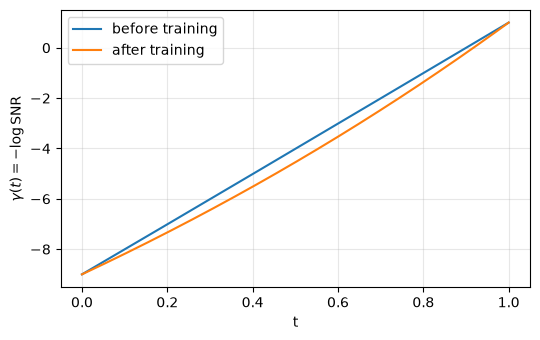

단조성 유지 확인


In [18]:
with torch.no_grad():
    before = gnet(tt).clone()

# 모양(l1,l2,l3)만 학습하고 끝점 gamma0/gamma1 은 고정한다
shape_params = list(gnet.l1.parameters()) + list(gnet.l2.parameters()) + list(gnet.l3.parameters())
opt = torch.optim.Adam(shape_params, lr=1e-2)
gen3 = torch.Generator().manual_seed(123)
for step in range(150):
    opt.zero_grad()
    loss = ld_uniform_t(gnet, 512, gen3).var()      # 몬테카를로 분산 최소화
    loss.backward()
    opt.step()
    if step % 50 == 0:
        print(f"step {step:3d}  var {loss.item():.4f}")

with torch.no_grad():
    after = gnet(tt).clone()

plt.figure(figsize=(5.5, 3.5))
plt.plot(tt, before, label="before training")
plt.plot(tt, after, label="after training")
plt.xlabel("t"); plt.ylabel(r"$\gamma(t) = -\log \mathrm{SNR}$")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
assert torch.all(torch.diff(after) > -1e-8), "학습 후에도 단조성은 유지되어야 한다"
print("단조성 유지 확인")

---
# 문제 5. Analytic-DPM — 최적 역분산의 해석적 형태

### 배경
Analytic-DPM 은 **사전 학습된 스코어 함수만 있으면 최적 역분산을 학습 없이 계산할 수 있음**을
보였다 (강의 식 4.4).

$$\Sigma_\theta(x_t,t)=\sigma_t^2+\Big(\sqrt{\tfrac{\bar\beta_t}{\alpha_t}}
-\sqrt{\bar\beta_{t-1}-\sigma_t^2}\Big)^{2}\cdot
\Big(1-\bar\beta_t\,\mathbb E_{x_t}\big\|\tfrac{\nabla_{x_t}\log q_t(x_t)}{\sqrt d}\big\|^2\Big)$$

여기서 $\bar\beta_t = 1-\bar\alpha_t$ 이고, $\sigma_t$ 는 역방향 체인의 자유 파라미터다.
DDPM 선택 $\sigma_t^2=\tilde\beta_t$ 를 넣으면 이 값은
$$\sigma_t^{\star 2}=\mathbb E_q\,\mathrm{tr}\big(\mathrm{Cov}_{q(x_{t-1}|x_t)}[x_{t-1}]\big)/d$$
즉 **진짜 최적 역분산과 정확히 일치**해야 한다.

### 검증 가능한 토이 설정
$x_0\sim\mathcal N(0, s^2 I_d)$ 이면 모든 것이 가우시안이라 정답을 손으로 쓸 수 있다.
- $q_t = \mathcal N(0, V_t I)$, $V_t=\bar\alpha_t s^2+(1-\bar\alpha_t)$
- $\nabla_x\log q_t(x) = -x/V_t$, 따라서 $\mathbb E\|\nabla\log q_t\|^2/d = 1/V_t$
- 최적 역분산 $=V_{t-1}-\dfrac{\alpha_t V_{t-1}^2}{V_t}$

### 과제
1. `score_norm_sq_over_d(sched, t, s2, n)` — $\mathbb E\|\nabla\log q_t\|^2/d$ 를 **몬테카를로로** 추정.
2. `analytic_dpm_variance(sched, t, sigma_t2, score_term)` — 식 (4.4).
3. `optimal_reverse_variance(sched, t, s2)` — 이변량 정규분포 조건부로부터 얻은 **정답**.

In [14]:
D_DIM = 4
S2_DATA = 4.0


def marginal_var(sched, t, s2):
    """V_t = abar_t * s2 + (1 - abar_t)"""
    return sched.alphas_cumprod[t] * s2 + (1.0 - sched.alphas_cumprod[t])


def score_norm_sq_over_d(sched, t, s2, n=200_000, d=D_DIM, gen=None):
    """E ||grad log q_t(x_t)||^2 / d 를 몬테카를로로 추정."""
    if gen is None:
        gen = torch.Generator().manual_seed(0)
    variance = marginal_var(sched, t, s2)
    x = torch.randn(n, d, generator=gen, dtype=sched.betas.dtype) * torch.sqrt(variance)
    score = -x / variance
    return score.square().sum(dim=1).mean() / d


def analytic_dpm_variance(sched, t, sigma_t2, score_term):
    """Analytic-DPM 식 (4.4)."""
    abar_t = sched.alphas_cumprod[t]
    abar_prev = sched.alphas_cumprod_prev[t]
    bbar_t = 1.0 - abar_t
    alpha_t = sched.alphas[t]
    first = torch.sqrt(bbar_t / alpha_t)
    second = torch.sqrt((1.0 - abar_prev - sigma_t2).clamp_min(0.0))
    return sigma_t2 + (first - second).square() * (1.0 - bbar_t * score_term)


def optimal_reverse_variance(sched, t, s2):
    """정답값: 이변량 정규 조건부 분산."""
    v_prev = marginal_var(sched, t - 1, s2)
    v_t = marginal_var(sched, t, s2)
    cov = torch.sqrt(sched.alphas[t]) * v_prev
    return v_prev - cov.square() / v_t


In [15]:
### 검증 (수정 금지)
gen = torch.Generator().manual_seed(2024)
print(f"{'t':>5} {'Analytic-DPM':>14} {'최적(정답)':>14} {'DDPM beta_tilde':>16} {'개선율':>8}")
for t in [1, 10, 100, 500, 999]:
    # (a) 몬테카를로 스코어 항이 해석해 1/V_t 와 맞는가
    V_t = marginal_var(sched, t, S2_DATA)
    mc = score_norm_sq_over_d(sched, t, S2_DATA, n=200_000, gen=gen)
    check(f"  score term (t={t})", mc, 1.0 / V_t, tol=2e-2)

    # (b) 식 (4.4) 가 최적 역분산과 정확히 일치하는가 (해석적 스코어 항 사용)
    sigma_t2 = sched.posterior_variance[t]
    got = analytic_dpm_variance(sched, t, sigma_t2, 1.0 / V_t)
    ref = optimal_reverse_variance(sched, t, S2_DATA)
    check(f"  eq(4.4) == 최적 (t={t})", got, ref, tol=1e-9)

    gain = (sigma_t2 - ref).abs() / ref
    print(f"{t:5d} {got.item():14.6e} {ref.item():14.6e} {sigma_t2.item():16.6e} {gain.item():8.2%}")

# (c) 고정 분산(beta_tilde)은 일반적으로 최적이 아니다
t = 1
assert (sched.posterior_variance[t] - optimal_reverse_variance(sched, t, S2_DATA)).abs() \
       / optimal_reverse_variance(sched, t, S2_DATA) > 0.1, \
       "이 설정에서는 beta_tilde 와 최적 분산이 뚜렷이 달라야 한다"
print("✅ 문제 5 통과")

    t   Analytic-DPM         최적(정답)  DDPM beta_tilde      개선율
  ok    score term (t=1): 최대 오차 2.514e-04
  ok    eq(4.4) == 최적 (t=1): 최대 오차 9.847e-17
    1   4.614335e-05   4.614335e-05     2.178950e-05   52.78%
  ok    score term (t=10): 최대 오차 1.924e-04
  ok    eq(4.4) == 최적 (t=10): 최대 오차 2.508e-16
   10   8.987742e-05   8.987742e-05     7.867762e-05   12.46%
  ok    score term (t=100): 최대 오차 2.959e-04
  ok    eq(4.4) == 최적 (t=100): 최대 오차 1.029e-16
  100   5.321099e-04   5.321099e-04     5.222236e-04    1.86%
  ok    score term (t=500): 최대 오차 3.465e-04
  ok    eq(4.4) == 최적 (t=500): 최대 오차 1.709e-16
  500   3.161648e-03   3.161648e-03     3.146005e-03    0.49%
  ok    score term (t=999): 최대 오차 2.173e-04
  ok    eq(4.4) == 최적 (t=999): 최대 오차 2.898e-14
  999   9.990073e-01   9.990073e-01     9.989976e-01    0.00%
✅ 문제 5 통과


---
# 문제 6. 확률 흐름 ODE로 **정확한** 로그 우도 계산

### 배경
스코어 기반 SDE
$$\mathrm dx=\big[f(x,t)-g^2(t)\nabla_x\log q_t(x)\big]\mathrm dt+g(t)\mathrm d\bar w$$
에 대응하는 **확률 흐름 ODE** 는

$$\frac{\mathrm dx_t}{\mathrm dt}=f(x_t,t)-\tfrac12 g^2(t)s_\theta(x_t,t)=:\tilde f_\theta(x_t,t)$$

이고, 순간 변수변환 공식으로부터 로그 우도를 **하한이 아니라 정확히** 계산할 수 있다.

$$\log p_\theta^{\mathrm{ode}}(x_0)=\log p_T(x_T)+\int_0^T \nabla\!\cdot\!\tilde f_\theta(x_t,t)\,\mathrm dt$$

$d$ 차원 발산 $\nabla\cdot\tilde f$ 를 정확히 구하려면 야코비안 대각합이 필요해 $O(d)$ 번의
역전파가 든다. 그래서 실제로는 **스킬링–허친슨 대각합 추정기**를 쓴다.

$$\nabla\cdot\tilde f_\theta(x_t,t)=\mathbb E_{p(\epsilon)}\big[\epsilon^\top\nabla\tilde f_\theta(x_t,t)\,\epsilon\big],
\qquad \mathbb E[\epsilon]=0,\ \mathrm{Cov}[\epsilon]=I$$

### 토이 설정 (정답을 손으로 아는 경우)
VP SDE: $\beta(t)=\beta_{\min}+t(\beta_{\max}-\beta_{\min})$, $f(x,t)=-\tfrac12\beta(t)x$, $g(t)=\sqrt{\beta(t)}$.
데이터 $x_0\sim\mathcal N(0,\Sigma)$ (상관 있는 2차원) 이면
$$q_t=\mathcal N\big(0,\ \bar\alpha(t)\Sigma+(1-\bar\alpha(t))I\big),\quad
\bar\alpha(t)=e^{-\int_0^t\beta(s)ds},\quad
\nabla\log q_t(x)=-\Sigma_t^{-1}x$$

따라서 ODE 로 구한 $\log p^{\mathrm{ode}}(x_0)$ 는 $\log\mathcal N(x_0;0,\Sigma)$ 와 일치해야 한다.

### 과제
1. `f_tilde(x, t)` — 확률 흐름 ODE 의 벡터장.
2. `exact_divergence(x, t)` — `torch.autograd.grad` 로 야코비안 대각합을 **정확히** 계산.
3. `hutchinson_divergence(x, t, eps)` — 라데마허 확률변수를 이용한 추정기.
4. `ode_logp(x0, n_steps, div_fn)` — 오일러 적분으로 $\log p^{\mathrm{ode}}(x_0)$ 계산.

In [16]:
D2 = 2
SIGMA = torch.tensor([[2.0, 1.2], [1.2, 1.0]])
BETA_MIN, BETA_MAX = 0.1, 20.0


def beta_fn(t):
    return BETA_MIN + t * (BETA_MAX - BETA_MIN)


def int_beta(t):
    return BETA_MIN * t + 0.5 * (BETA_MAX - BETA_MIN) * t ** 2


def sigma_t_mat(t):
    """q_t 의 공분산 abar(t) * SIGMA + (1-abar(t)) I"""
    ab = torch.exp(-int_beta(torch.as_tensor(t, dtype=torch.float64)))
    return ab * SIGMA + (1.0 - ab) * torch.eye(D2)


def score_fn(x, t):
    """해석적 스코어 -Sigma_t^{-1} x   (x: (N,D))"""
    return -torch.linalg.solve(sigma_t_mat(t), x.T).T


def f_tilde(x, t):
    """확률 흐름 ODE 의 벡터장."""
    beta = beta_fn(t)
    return -0.5 * beta * x - 0.5 * beta * score_fn(x, t)


def exact_divergence(x, t):
    """야코비안 대각합을 정확히 계산."""
    x = x.detach().requires_grad_(True)
    out = f_tilde(x, t)
    divergence = torch.zeros(x.shape[0], dtype=x.dtype, device=x.device)
    for i in range(x.shape[1]):
        divergence = divergence + torch.autograd.grad(
            out[:, i].sum(), x, retain_graph=True
        )[0][:, i]
    return divergence


def hutchinson_divergence(x, t, eps):
    """eps^T J eps 를 vector-Jacobian product 한 번으로 계산."""
    x = x.detach().requires_grad_(True)
    out = f_tilde(x, t)
    grad = torch.autograd.grad((out * eps).sum(), x)[0]
    return (grad * eps).sum(dim=1)


def log_gaussian(x, cov):
    sign, logdet = torch.linalg.slogdet(cov)
    quad = (x * torch.linalg.solve(cov, x.T).T).sum(dim=1)
    return -0.5 * (D2 * math.log(2 * math.pi) + logdet + quad)


def ode_logp(x0, n_steps=2000, div_fn=None):
    """log p^ode(x0) = log p_T(x_T) + int_0^1 div f_tilde dt."""
    if div_fn is None:
        div_fn = lambda x, t: exact_divergence(x, t)
    x = x0.clone()
    dt = 1.0 / n_steps
    logdet = torch.zeros(x.shape[0], dtype=x.dtype, device=x.device)
    for step in range(n_steps):
        t = step * dt
        logdet = logdet + div_fn(x, t) * dt
        x = x + f_tilde(x, t) * dt
    return log_gaussian(x, sigma_t_mat(1.0)) + logdet


In [17]:
### 검증 (수정 금지)
x0 = torch.tensor([[0.5, -1.2], [1.1, 0.4], [-0.3, 0.9]])

# (a) 정확한 발산이 해석해와 일치: J = -0.5*beta(t)*(I - Sigma_t^{-1})
for t in [0.0, 0.3, 0.7, 1.0]:
    J = -0.5 * beta_fn(t) * (torch.eye(D2) - torch.linalg.inv(sigma_t_mat(t)))
    check(f"exact div (t={t})", exact_divergence(x0, t), J.trace().expand(3), tol=1e-9)

# (b) 허친슨 추정기는 불편(unbiased)
t = 0.5
J = -0.5 * beta_fn(t) * (torch.eye(D2) - torch.linalg.inv(sigma_t_mat(t)))
gen = torch.Generator().manual_seed(5)
M = 200_000
xr = x0[:1].repeat(M, 1)
eps = torch.randint(0, 2, (M, D2), generator=gen).to(torch.float64) * 2 - 1  # Rademacher
est = hutchinson_divergence(xr, t, eps)
print(f"  허친슨 평균 {est.mean().item():.5f}  vs  정확한 대각합 {J.trace().item():.5f}"
      f"  (표본표준편차 {est.std().item():.3f})")
check("허친슨 불편성", est.mean(), J.trace(), tol=3e-2)

# (c) ODE 로 구한 로그 우도가 진짜 로그 밀도와 일치
lp = ode_logp(x0, n_steps=2000)
true = log_gaussian(x0, SIGMA)
for i in range(3):
    print(f"  x0={x0[i].tolist()}  ODE {lp[i].item():.6f}   정답 {true[i].item():.6f}")
check("PF-ODE 로그 우도", lp, true, tol=3e-3)

# (d) 오일러 스텝을 늘리면 오차가 줄어든다
e_coarse = (ode_logp(x0, 250) - true).abs().max()
e_fine = (ode_logp(x0, 2000) - true).abs().max()
print(f"  250 스텝 오차 {e_coarse:.2e} -> 2000 스텝 오차 {e_fine:.2e}")
assert e_fine < e_coarse, "적분 스텝을 늘리면 오차가 줄어야 한다"
print("✅ 문제 6 통과")

  ok  exact div (t=0.0): 최대 오차 2.776e-17
  ok  exact div (t=0.3): 최대 오차 4.996e-16
  ok  exact div (t=0.7): 최대 오차 3.261e-16
  ok  exact div (t=1.0): 최대 오차 2.220e-16
  허친슨 평균 -0.28803  vs  정확한 대각합 -0.28674  (표본표준편차 0.891)
  ok  허친슨 불편성: 최대 오차 1.292e-03
  x0=[0.5, -1.2]  ODE -5.625611   정답 -5.628325
  x0=[1.1, 0.4]  ODE -1.970955   정답 -1.971182
  x0=[-0.3, 0.9]  ODE -3.651907   정답 -3.653325
  ok  PF-ODE 로그 우도: 최대 오차 2.714e-03
  250 스텝 오차 2.19e-02 -> 2000 스텝 오차 2.71e-03
✅ 문제 6 통과


### 6-2. (참고) 허친슨 추정기의 비용/정확도 절충
프로브 개수 $M$ 을 늘릴수록 로그 우도 추정의 오차가 줄어든다.
*(채점 대상 아님)*

In [19]:
x_single = torch.tensor([[0.5, -1.2]])
true1 = log_gaussian(x_single, SIGMA)[0]
gen = torch.Generator().manual_seed(99)
print(f"{'M':>5} {'평균 |오차|':>12}")
for M in [1, 4, 16, 64]:
    errs = []
    for _ in range(3):
        eps = torch.randint(0, 2, (M, D2), generator=gen).to(torch.float64) * 2 - 1
        div_fn = lambda x, t: hutchinson_divergence(
            x.repeat(M, 1), t, eps).mean().reshape(1)
        errs.append((ode_logp(x_single, 400, div_fn) - true1).abs().item())
    print(f"{M:5d} {np.mean(errs):12.4f}")
print("\n→ 정확한 발산은 O(d)번의 역전파가 필요하지만, 허친슨은 M번으로 끝난다.")
print("  고차원(이미지)에서는 이 절충이 로그 우도 평가를 실제로 가능하게 만든다.")

    M      평균 |오차|
    1       1.2228
    4       0.2076
   16       0.2076
   64       0.0426

→ 정확한 발산은 O(d)번의 역전파가 필요하지만, 허친슨은 M번으로 끝난다.
  고차원(이미지)에서는 이 절충이 로그 우도 평가를 실제로 가능하게 만든다.


---
## 마무리 — 제출 전 체크리스트

- [ ] 문제 1~6 의 `✅ 문제 N 통과` 가 모두 출력되었는가?
- [ ] 문제 1 의 관찰 주석을 채웠는가?
- [ ] `런타임 → 모두 다시 실행` 으로 처음부터 끝까지 오류 없이 돌아가는가?

### 한 줄 요약
| 접근 | 무엇을 학습/계산하는가 | 얻는 것 |
|---|---|---|
| 코사인 스케줄 (IDDPM) | 고정된 더 나은 $\bar\alpha_t$ | 전 시점에 고르게 유용한 학습 신호 |
| 학습형 역분산 (IDDPM) | $v \Rightarrow \Sigma_\theta$ | 더 타이트한 $L_\mathrm{VLB}$ |
| VDM | $\gamma_\eta(t)$ 를 공동 학습 | 기댓값은 불변, **분산**이 줄어 학습 안정 |
| Analytic-DPM | 학습 없이 최적 분산을 **해석적으로** | 재학습 없이 우도/샘플 품질 개선 |
| PF-ODE + 허친슨 | 하한이 아닌 **정확한** $\log p(x_0)$ | 모델 간 공정한 우도 비교 |
